# **Detecção de Doenças Cardíacas com Machine Learning**

## **1. Introdução**

<p align="justify">
A saúde cardiovascular é uma das principais preocupações em todo o mundo, sendo uma das principais causas de morbidade e mortalidade. A detecção precoce e o diagnóstico preciso de doenças cardíacas são essenciais para a melhoria da qualidade de vida e redução de riscos de complicações fatais. Com os avanços tecnológicos e o crescente volume de dados de saúde, técnicas de aprendizado de máquina têm se mostrado eficazes na identificação e no diagnóstico de doenças cardíacas, facilitando o trabalho dos profissionais de saúde e permitindo tratamentos mais rápidos e personalizados.

<p align="justify">
Neste projeto, exploraremos o uso de algoritmos de Machine Learning (ML) para prever a presença de doenças cardíacas com base em um conjunto de dados amplamente utilizado, o Heart Disease Dataset. Este conjunto de dados contém informações sobre características de pacientes, como idade, sexo, níveis de colesterol, pressão arterial, histórico médico e outros fatores relevantes para a detecção de doenças cardíacas. O objetivo é desenvolver um modelo preditivo que consiga identificar pacientes com maior risco de apresentar doenças cardíacas, fornecendo assim uma ferramenta útil para médicos e profissionais da saúde.

In [33]:
# Carregando biblioteca

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [34]:
sns.set()

In [35]:
# Carregando base de dados

dados = pd.read_csv('/content/drive/MyDrive/Portfólio/Dados/Heart Disease.csv', sep = ';')

In [36]:
# Visualizando base de dados

dados.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## **2. Análise Exploratória de Dados**

In [37]:
# Informação sobre os dados

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(12), int64(1), object(1)
memory usage: 33.3+ KB


In [38]:
# Distribuição dos dados

dados.shape

(303, 14)

In [39]:
# Estatística descritiva dos dados

dados.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.666667,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.933790,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


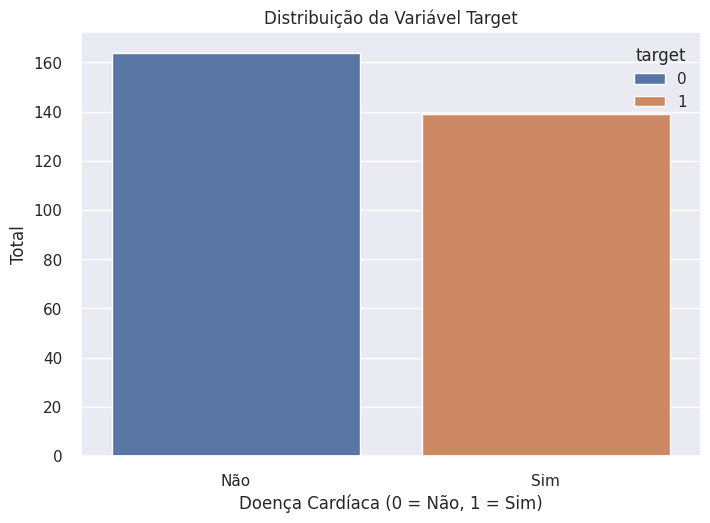

In [40]:
# Gráfico 1: Distribuição da variável target

sns.countplot(x = 'target',
              data = dados,
              hue = 'target')

plt.title('Distribuição da Variável Target')
plt.xlabel('Doença Cardíaca (0 = Não, 1 = Sim)')
plt.ylabel('Total')
plt.xticks([0, 1], ['Não', 'Sim'])

plt.show();

**Obs 1:** A partir do gráfico 1, pode-se verificar que existe mais informações de pacientes sem doença cardiaca, pouco mais de 160 pacientes.

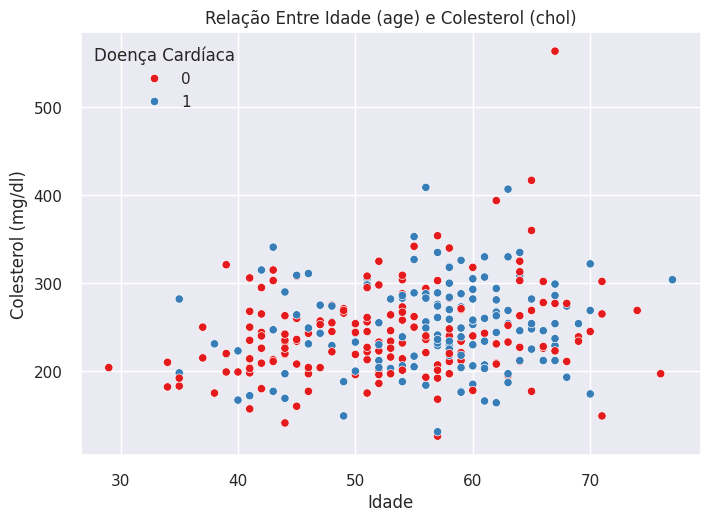

In [41]:
# Gráfico 2: Relação entre Idade (age) e Colesterol (chol)

sns.scatterplot(x = 'age',
                y = 'chol',
                hue = 'target',
                palette='Set1',
                data = dados)

plt.title('Relação Entre Idade (age) e Colesterol (chol)')
plt.xlabel('Idade')
plt.ylabel('Colesterol (mg/dl)')
plt.legend(title = 'Doença Cardíaca',
           loc = 'upper left')

plt.show()

**Obs 2:** Observando as informações apresentadas no gráfico 2, pode-se verificar que a maioria dos paciente estão com o Colesterol entre 100 mg/dl e 400 mg/dl. Quando analisamos os grupos separademente, nota-se que a maioria dos pacientes acometidos por doenças cardíacas tem entre 50 e 65 anos, enquanto os pacientes saudáveis sua maioria tem entre 30 e 60 anos.

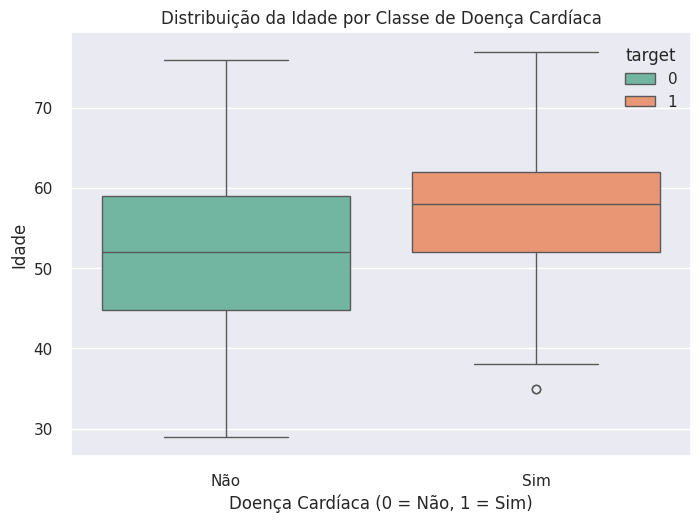

In [42]:
# Gráfico 3: Distribuição das Idades (age) por Classe de Doença Cardíaca

sns.boxplot(x = 'target',
            y = 'age',
            data = dados,
            hue = 'target',
            palette = 'Set2')

plt.title('Distribuição da Idade por Classe de Doença Cardíaca')
plt.xlabel('Doença Cardíaca (0 = Não, 1 = Sim)')
plt.ylabel('Idade')
plt.xticks([0, 1], ['Não', 'Sim'])

plt.show()

**Obs 3**: Analisando as informações apresentadas no gráfico 3, as pessoas com doenças cardíacas tem em média 58 anos e a o maior número de pacientes tem entre 50 e 62 anos. Já em relação aos pacientes que não possuem nenhuma doença cardíaca, a sua maioria estão entre 45 e 59 anos, e a média de idade é de 52 anos. Vale ressalta que um paciente acometido por algum tipo de doença cardíaca tem algo em torno de 35 anos, fugindo do padrão apresentado pelo grupo.

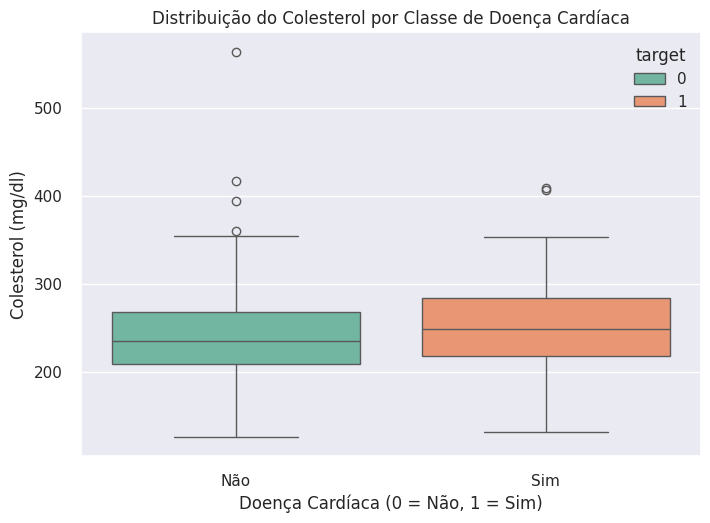

In [43]:
# Gráfico 4: Distribuição do Colesterol (chol) por Classe de Doença Cardíaca

sns.boxplot(x = 'target',
            y = 'chol',
            data = dados,
            hue = 'target',
            palette = 'Set2')

plt.title('Distribuição do Colesterol por Classe de Doença Cardíaca')
plt.xlabel('Doença Cardíaca (0 = Não, 1 = Sim)')
plt.ylabel('Colesterol (mg/dl)')
plt.xticks([0, 1], ['Não', 'Sim'])

plt.show()

**Obs 4:** As informações apresentadas no gráfica 4 mostram que os pacientes com doença cardíaca tendem a apresentar níveis mais elevados de colesterol, mas a sobreposição dos valores indica que colesterol elevado não é um indicador isolado de risco.

* **Pacientes sem Doença Cardíaca:** A mediana dos níveis de colesterol parece levemente mais baixa, e há menos valores extremos (outliers).

* **Pacientes com Doença Cardíaca:** Apresentam uma mediana um pouco mais alta e maior número de valores extremos (outliers).

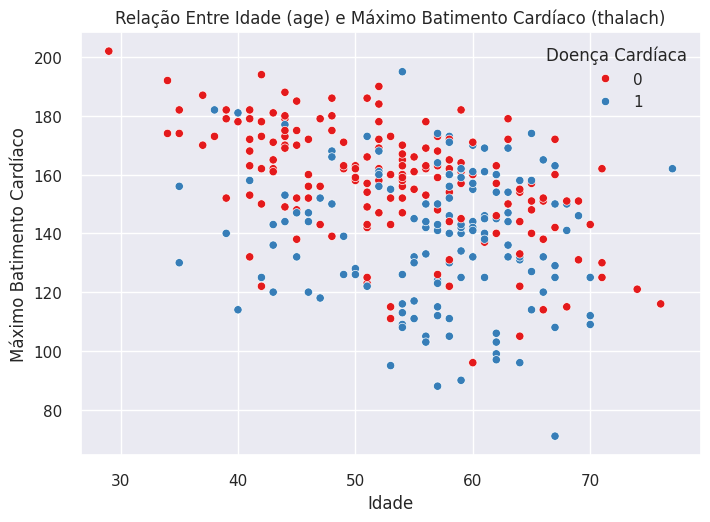

In [44]:
# Gráfico 5: Relação entre Idade e Máximo Batimento Cardíaco (thalach)

sns.scatterplot(x = 'age',
                y = 'thalach',
                hue = 'target',
                data = dados,
                palette = 'Set1')

plt.title('Relação Entre Idade (age) e Máximo Batimento Cardíaco (thalach)')
plt.xlabel('Idade')
plt.ylabel('Máximo Batimento Cardíaco')
plt.legend(title = 'Doença Cardíaca')

plt.show()

**Obs 5:** As informações apresentadas no gráfico 5 sugere uma relação inversa entre a idade e o máximo batimento cardíaco. À medida que a idade aumenta, o valor máximo de batimento cardíaco tende a diminuir.

* **Pacientes com Doença Cardíaca (azul):** Os valores de batimento cardíaco máximo tendem a ser menores.

* **Pacientes sem Doença Cardíaca (vermelho):** Apresentam maior dispersão nos valores de batimento cardíaco máximo.

Idade elevada e batimentos cardíacos máximos mais baixos podem estar associados a um maior risco de doença cardíaca.

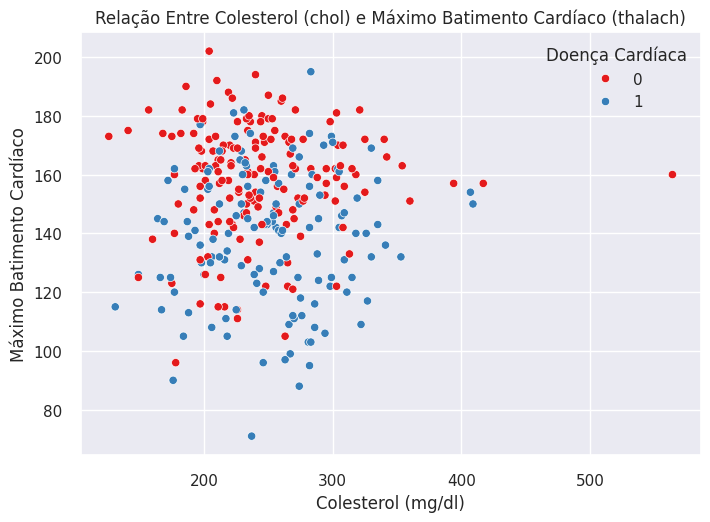

In [45]:
# Gráfico 6: Relação entre Colesterol e Máximo Batimento Cardíaco

sns.scatterplot(x = 'chol',
                y = 'thalach',
                hue = 'target',
                data = dados,
                palette = 'Set1')

plt.title('Relação Entre Colesterol (chol) e Máximo Batimento Cardíaco (thalach)')
plt.xlabel('Colesterol (mg/dl)')
plt.ylabel('Máximo Batimento Cardíaco')
plt.legend(title = 'Doença Cardíaca')

plt.show()

**Obs 6:** A ausência de correlação direta sugere que colesterol e batimento cardíaco devem ser analisados em conjunto com outros fatores para prever risco de doença cardíaca.

* Não parece haver uma relação clara entre colesterol e batimento cardíaco máximo.
* Os pacientes com doença cardíaca (azul) tendem a ter batimentos cardíacos mais baixos, independentemente dos níveis de colesterol.
* Os pacientes sem doença cardíaca (vermelho) estão distribuídos de forma mais dispersa, tanto em relação ao colesterol quanto ao batimento cardíaco.

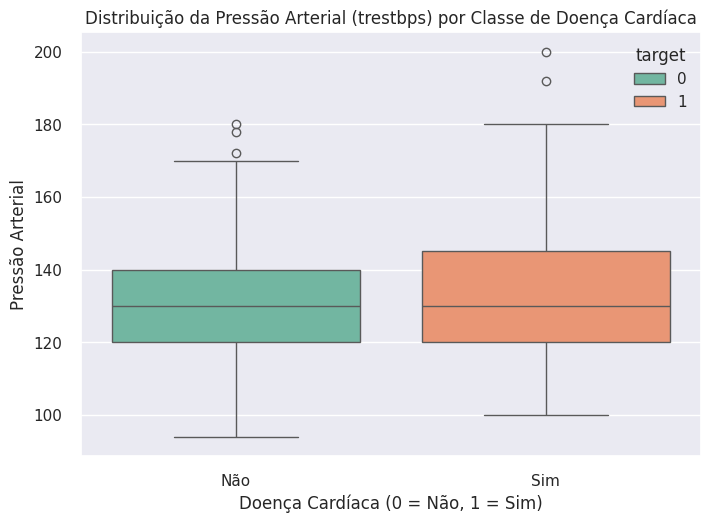

In [46]:
# Gráfico 7: Distribuição do Trestbps (Pressão Arterial) por Classe de Doença Cardíaca

sns.boxplot(x = 'target',
            y = 'trestbps',
            data = dados,
            hue = 'target',
            palette = 'Set2')

plt.title('Distribuição da Pressão Arterial (trestbps) por Classe de Doença Cardíaca')
plt.xlabel('Doença Cardíaca (0 = Não, 1 = Sim)')
plt.ylabel('Pressão Arterial')
plt.xticks([0, 1], ['Não', 'Sim'])

plt.show()

**Obs 7:** O gráfico 7 compara os níveis de pressão arterial em repouso (trestbps) entre pacientes com e sem doença cardíaca. Com base nele, chegou-se as seguintes observações:

**Pacientes sem Doença Cardíaca (verde):**
* A mediana dos valores de pressão arterial é menor (~120 mmHg).
* Há uma dispersão menor, indicando que os valores estão mais concentrados próximos à mediana.
* Existem poucos valores atípicos (outliers) acima de 140 mmHg.

**Pacientes com Doença Cardíaca (laranja):**
* A mediana dos valores de pressão arterial é maior (~130 mmHg).
* Os valores são mais dispersos, cobrindo uma faixa maior de pressão arterial, incluindo valores altos (~180-200 mmHg).
* Apresentam mais valores extremos (outliers), o que pode indicar maior variação da pressão arterial em pacientes com doença cardíaca.

Os Pacientes com doença cardíaca tendem a ter uma pressão arterial em repouso (trestbps) mais elevada e mais variada em comparação com pacientes sem doença cardíaca. No entanto, a sobreposição significativa das distribuições sugere que a pressão arterial sozinha não é suficiente para discriminar a presença ou ausência de doença cardíaca.

## **3. Pré-Processamento de Dados**

In [47]:
# Removendo valores inconsistentes

# Substituir os valores '?' por NaN
dados.replace('?', pd.NA, inplace = True)

# Remover as linhas que contêm NaN (valores ausentes)
dados = dados.dropna()

In [48]:
# Verificando informações dos dados

dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 301 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       301 non-null    float64
 1   sex       301 non-null    float64
 2   cp        301 non-null    float64
 3   trestbps  301 non-null    float64
 4   chol      301 non-null    float64
 5   fbs       301 non-null    float64
 6   restecg   301 non-null    float64
 7   thalach   301 non-null    float64
 8   exang     301 non-null    float64
 9   oldpeak   301 non-null    float64
 10  slope     301 non-null    float64
 11  ca        301 non-null    float64
 12  thal      301 non-null    object 
 13  target    301 non-null    int64  
dtypes: float64(12), int64(1), object(1)
memory usage: 35.3+ KB


In [49]:
# Separando os dados em previsores e classe

previsores = dados.iloc[:, :-1].values
classe = dados.iloc[:, -1].values

In [50]:
# Normalizando os dados

scaler = StandardScaler()
previsores = scaler.fit_transform(previsores)

In [51]:
# Dividindo os dados em treino e teste

X_treino, X_teste, y_treino, y_teste = train_test_split(previsores,
                                                        classe,
                                                        test_size = 0.3,
                                                        random_state = 0)

In [52]:
# Verificando a distribuição dos dados

print(X_treino.shape)
print(y_treino.shape)
print(X_teste.shape)
print(y_teste.shape)

(210, 13)
(210,)
(91, 13)
(91,)


## **4. Construindo Modelo**

In [53]:
# Instalando o pycaret

#!pip install pycaret

In [54]:
# Carregando pycaret

from pycaret.classification import *

In [55]:
# Comparando modelos com pycaret

clf = setup(data = dados,
            target = 'target',
            session_id = 123)

compare_models()

,Description,Value
0,Session id,123
1,Target,target
2,Target type,Binary
3,Original data shape,"(301, 14)"
4,Transformed data shape,"(301, 16)"
5,Transformed train set shape,"(210, 16)"
6,Transformed test set shape,"(91, 16)"
7,Numeric features,12
8,Categorical features,1
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8476,0.9093,0.7744,0.8878,0.8205,0.6910,0.7036,0.9990
ridge,Ridge Classifier,0.8381,0.9066,0.7522,0.8838,0.8067,0.6705,0.6836,0.0650
lda,Linear Discriminant Analysis,0.8381,0.9048,0.7522,0.8838,0.8067,0.6705,0.6836,0.1040
rf,Random Forest Classifier,0.8333,0.8970,0.7722,0.8584,0.8059,0.6615,0.6729,0.2360
et,Extra Trees Classifier,0.8238,0.9089,0.7744,0.8365,0.7966,0.6439,0.6547,0.3840
lightgbm,Light Gradient Boosting Machine,0.8238,0.8891,0.8144,0.8104,0.8032,0.6449,0.6584,0.2140
nb,Naive Bayes,0.8190,0.8809,0.8144,0.8013,0.8042,0.6362,0.6415,0.0630
ada,Ada Boost Classifier,0.8143,0.8205,0.7833,0.8093,0.7915,0.6248,0.6307,0.1740
gbc,Gradient Boosting Classifier,0.8095,0.8682,0.7644,0.8205,0.7787,0.6151,0.6297,0.3050
xgboost,Extreme Gradient Boosting,0.8095,0.8781,0.7844,0.8017,0.7809,0.6150,0.6273,0.1100


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [56]:
# Carregando biblioteca para o modelo de Regressão Logistíca

from sklearn.linear_model import LogisticRegression

In [57]:
# Instanciando modelo

modelo = LogisticRegression(C=1.0,
                            class_weight = None,
                            dual = False,
                            fit_intercept = True,
                            intercept_scaling = 1,
                            l1_ratio = None,
                            max_iter = 1000,
                            multi_class = 'auto',
                            n_jobs = None,
                            penalty = 'l2',
                            random_state = 123,
                            solver = 'lbfgs',
                            tol = 0.0001,
                            verbose = 0,
                            warm_start = False)

In [58]:
# Treinando o modelo

modelo.fit(X_treino, y_treino)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [59]:
# Aplicando aos dados de teste

y_predito = modelo.predict(X_teste)

In [60]:
# Modelo para dizer a probabilidade de ser uma classe ou outra
prob_class = modelo.predict_proba(X_teste)

# Transformando em um dataframe
df_prob_class = pd.DataFrame(prob_class)

In [61]:
# Visualizando dados

df_prob_class.head()

,0,1
0,0.386541,0.613459
1,0.922561,0.077439
2,0.855251,0.144749
3,0.756152,0.243848
4,0.732303,0.267697


## **5. Avaliando Modelo**

In [62]:
# Métricas de Avaliação

print(classification_report(y_teste, y_predito))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87        50
           1       0.85      0.83      0.84        41

    accuracy                           0.86        91
   macro avg       0.86      0.85      0.86        91
weighted avg       0.86      0.86      0.86        91



## **6. Considerações Finais**

<p align="justify">
Os resultados obtidos a partir do modelo de Machine Learning aplicado ao conjunto de dados de doenças cardíacas indicam um desempenho geral muito positivo, com a precisão e a capacidade de prever corretamente os casos de doença cardíaca sendo bastante equilibradas. A precisão de 86% e o f1-score médio de 0.86 demonstram que o modelo tem uma boa capacidade para distinguir entre pacientes com e sem doenças cardíacas.

<p align="justify">
Ao analisar as métricas de cada classe, observamos que, para a classe "0" (ausência de doença cardíaca), o modelo apresenta uma precisão de 0.86 e um recall de 0.88, o que indica que ele é eficaz em identificar pacientes sem a doença, com uma taxa de falsos negativos relativamente baixa. Para a classe "1" (presença de doença cardíaca), embora o modelo ainda mantenha um f1-score de 0.84, a precisão de 0.85 e o recall de 0.83 indicam que o modelo tem uma leve tendência a falhar na identificação de todos os casos positivos, cometendo um número maior de falsos negativos em comparação aos falsos positivos. Contudo, esse desempenho é ainda muito satisfatório para um sistema de suporte à decisão clínica.

<p align="justify">
A acurácia geral do modelo foi de 86%, o que reflete uma taxa de acertos relativamente alta, mostrando que o modelo tem bom desempenho tanto para a classe 0 quanto para a classe 1. A análise de média ponderada e média macro confirma a consistência do modelo, pois as métricas de precisão, recall e f1-score estão equilibradas entre as classes, sem indicar um viés significativo para uma das classes em detrimento da outra.

<p align="justify">
Embora o modelo tenha mostrado um bom desempenho geral, ainda existem oportunidades de melhoria.

<p align="justify">
Em resumo, o modelo desenvolvido apresenta um desempenho robusto na tarefa de predizer doenças cardíacas e pode ser uma ferramenta valiosa para a triagem de pacientes em ambientes clínicos. No entanto, como qualquer sistema preditivo, é importante que ele seja constantemente aprimorado e validado com novos dados, a fim de garantir sua eficácia e precisão no contexto real de diagnóstico médico.